# PARTE 1 E 2

In [1]:
#Pandas Series -> https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html
#importar biblioteca
import pandas as pd

In [2]:
#Inserindo os dados - 2 maneiras de fazer o upload dos dados, sendo via link ou caminho de pasta.

# notas = pd.read_csv("C:/Users/user/Desktop/Data Science/DataScience_ALURA/Base_Dados/ratings.csv)
notas = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/data-science-analise-exploratoria/main/Aula_0/ml-latest-small/ratings.csv")
notas

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [3]:
notas.info() #É possivel observar a quantidade de registros e colunas, o tipo das variáveis da coluna(float64 e int64), se possuem dados nulos e o uso de memoria daqueles dados

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [4]:
#Descobrir o formato da tabela
notas.shape

(100836, 4)

In [5]:
notas.columns = ["usuarioId", "filmeId", "nota", "momento"] #Trocando os nomes das colunas
notas.head() #Ver as 5 primeiras linhas

,usuarioId,filmeId,nota,momento
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
notas["nota"].unique() #Extraindo os valores unicos que a tabela possue.

array([4. , 5. , 3. , 2. , 1. , 4.5, 3.5, 2.5, 0.5, 1.5])

In [7]:
notas["nota"].value_counts() #Contagem dos valores unicos na tabela " Nota "

nota
4.0    26818
3.0    20047
5.0    13211
3.5    13136
4.5     8551
2.0     7551
2.5     5550
1.0     2811
1.5     1791
0.5     1370
Name: count, dtype: int64

In [8]:
notas["nota"].mean() #Mostrando a média dos valores da coluna " Nota "

np.float64(3.501556983616962)

<Axes: ylabel='Frequency'>

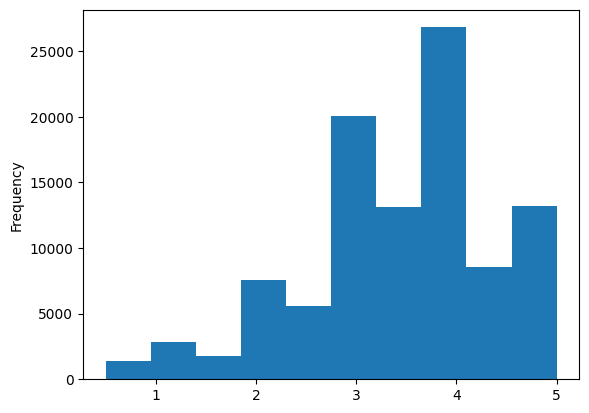

In [9]:
notas["nota"].plot(kind='hist') # Construindo gráfico, "Kind" = ~Tipo e "hist" = histograma

In [10]:
notas["nota"].median() #Mostrando a Mediana da coluna " NOTA "

np.float64(3.5)

In [11]:
mediana = notas["nota"].median()
media = notas["nota"].mean()
print(f"A mediana é {mediana}")
print(f"A média é {media}")

A mediana é 3.5
A média é 3.501556983616962


In [12]:
notas["nota"].describe() #Extraindo as medidas, como: contagem("count"), media(mean), valores minimos, medios e maximos (min, 50% e max)

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: nota, dtype: float64

In [13]:
#" GRAFICOS DIFERENTES TEM PAPEIS DIFERENTES E TRAZEM INFORMAÇÕES DIFERENTES "

<Axes: ylabel='nota'>

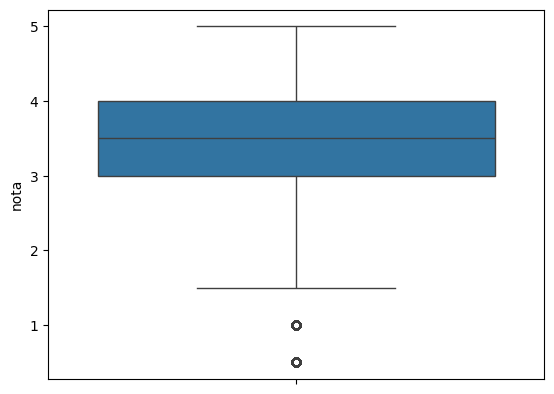

In [14]:
import seaborn as sns

sns.boxplot(notas["nota"]) #Ajuda a perceber a distribuição dos dados. Dessa forma, identificando onde a maioria dos valores se concentra e se há valores muito diferentes dos demais.

In [15]:
#TESTANDO SERIES

# Criando um Series simples
notas_SERIES = pd.Series([10, 8, 4, 10, 3, 1])
notas_SERIES

0    10
1     8
2     4
3    10
4     3
5     1
dtype: int64

In [16]:
notas_SERIES.index #Os dados estao partindo do 0 até 6

RangeIndex(start=0, stop=6, step=1)

In [17]:
notas_SERIES.sort_values() #Assim, podemos ordernar os valores em ordem crescente, sem alterar os índices

5     1
4     3
2     4
1     8
3    10
0    10
dtype: int64

In [18]:
filmes = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/data-science-analise-exploratoria/main/Aula_0/ml-latest-small/movies.csv")
filmes.columns = ["filmeId", "titulo", "generos"] #Trocando o nome das colunas.
filmes.head()

,filmeId,titulo,generos
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [19]:
notas.head()

,usuarioId,filmeId,nota,momento
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [20]:
notas.query("filmeId==1")["nota"].mean() #Pesquisando a nota média do filme com o Id = 1 (TOYSTORY)

np.float64(3.9209302325581397)

In [21]:
notas.query("filmeId==2")["nota"].mean() #Pesquisando a nota média do filme com o Id = 2 (JUMANJI)

np.float64(3.4318181818181817)

In [22]:
medias_por_filme = notas.groupby("filmeId")["nota"].mean()  #Agrupando todos os filmes e tirando a média deles (Individualmente)
medias_por_filme.head()                                     #Colocando dentro de uma variável afins de boas práticas

filmeId
1    3.920930
2    3.431818
3    3.259615
4    2.357143
5    3.071429
Name: nota, dtype: float64

<Axes: ylabel='Frequency'>

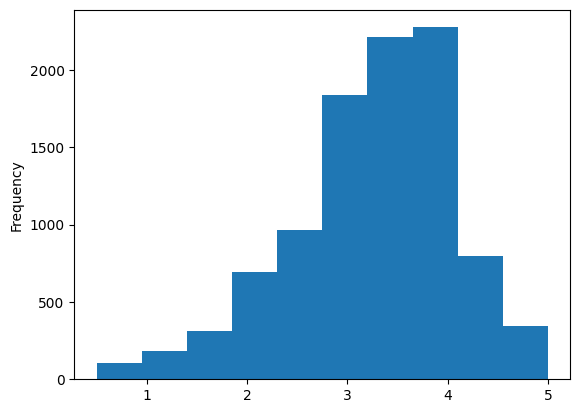

In [23]:
medias_por_filme.plot(kind='hist')

### Exercício
- Descobrir:
    - Somatório de todas as vendas de “Ratatouille” do período;
    - Frequência dos métodos de pagamento para o “Ratatouille”;


In [24]:
vendas = pd.read_csv("serenatto_2sem_2023.csv")
vendas.columns = ("iD", "Data", "Produto", "Valor", "Pagamento")
vendas.head()

,iD,Data,Produto,Valor,Pagamento
0,2720,2023-07-01,Risoto de Funghi,13.0,Cartão de Débito
1,2721,2023-07-02,Tiramisù,10.0,Cartão de Débito
2,2722,2023-07-02,Tiramisù,10.0,Cartão de Crédito
3,2723,2023-07-02,Ratatouille,8.5,PIX
4,2724,2023-07-03,Ratatouille,8.5,Dinheiro


In [25]:
somatorio_vendas = vendas.query("Produto=='Ratatouille'").Valor.sum()
print(f"A somatória de vendas dos items 'Ratatouille' foi de R${somatorio_vendas}")

A somatória de vendas dos items 'Ratatouille' foi de R$323.0


In [26]:
frequencia_pagamento = vendas.query("Produto=='Ratatouille'").Pagamento.value_counts()
print(f"A frequencia dos métodos de pagamento sob o produto 'Ratatouille' foi: \n{frequencia_pagamento}")

A frequencia dos métodos de pagamento sob o produto 'Ratatouille' foi: 
Pagamento
PIX                  13
Cartão de Débito     10
Dinheiro              9
Cartão de Crédito     6
Name: count, dtype: int64


###

<Axes: ylabel='nota'>

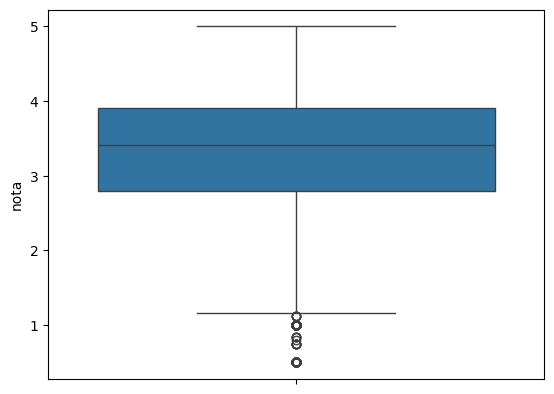

In [27]:
sns.boxplot(medias_por_filme) #Mostrando a distribuição das minhas notas dos filmes por filmes e a mediana.

In [28]:
medias_por_filme.describe()

count    9724.000000
mean        3.262448
std         0.869874
min         0.500000
25%         2.800000
50%         3.416667
75%         3.911765
max         5.000000
Name: nota, dtype: float64

Text(0.5, 1.0, 'Histograma das médias dos filmes')

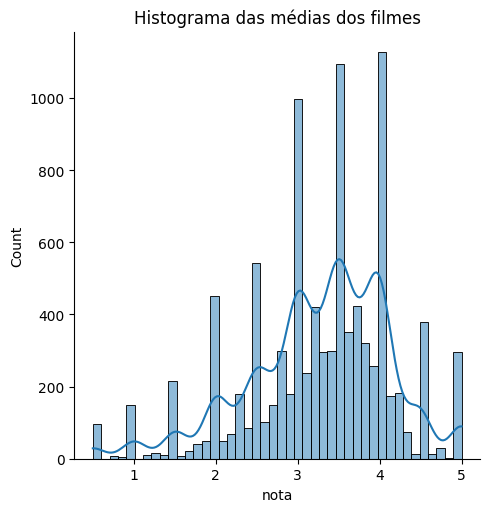

In [29]:
import matplotlib.pyplot as plt

sns.displot(medias_por_filme, kde=True) #Acrescenta mais baldes ao grafico, deixando mais claro a contagem de cada uma das notas medias
plt.title("Histograma das médias dos filmes") #O titulo deve ser sempre após a função de criar o grafico.
                                        #Kde=true - Mostra uma curva de como essa função comportaria

O que eu aprendi nessa parte do curso:
- Trabalhar com o método query() para filtrar linhas de um DataFrame com base em uma expressão;
- Realizar o agrupamento dos dados a partir de uma coluna por meio do método groupby();
- Extrair dados filtrando uma única coluna;
- Modificar os “bins” (intervalos) de um histograma verificando o seu comportamento;
- Identificar as diferentes bibliotecas de visualização, como Matplotlib e Seaborn;
- Inserir textos no notebook para explicar os dados e criar um storytelling de nossas análises.

# PARTE 3 e 4

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [31]:
tmdb = pd.read_csv("https://raw.githubusercontent.com/alura-cursos/data-science-analise-exploratoria/main/Aula_0/tmdb_5000_movies.csv")
tmdb.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


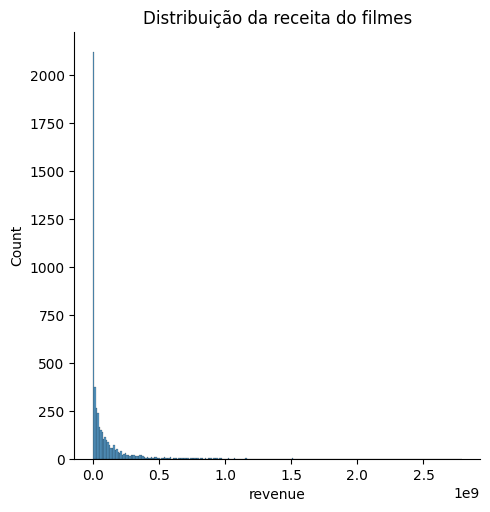

In [32]:
sns.displot(tmdb["revenue"])
plt.title("Distribuição da receita do filmes")
plt.show()

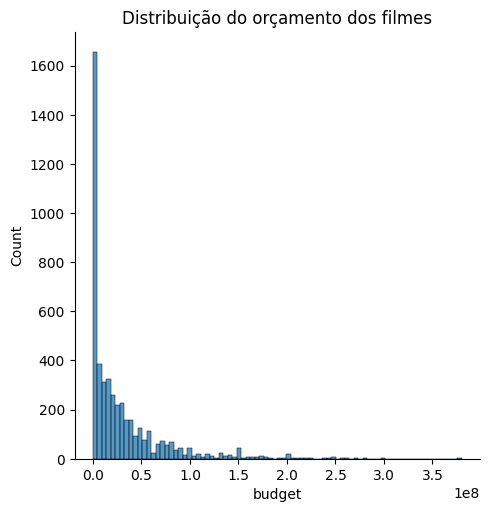

In [33]:
sns.displot(tmdb["budget"])
plt.title("Distribuição do orçamento dos filmes")
plt.show()

In [34]:
tmdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [35]:
tmdb.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


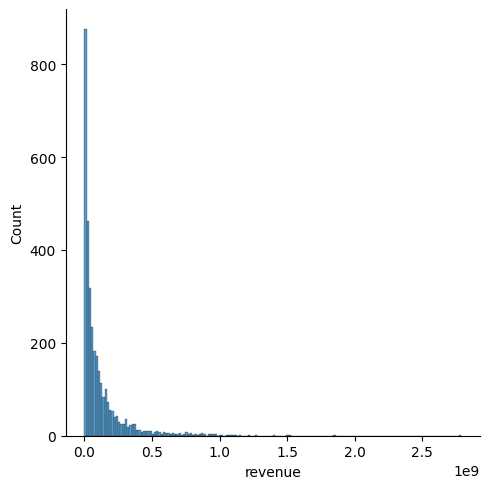

In [36]:
#Criando a variavel para pegar apenas os filmes que possuem faturamento acima de 0. Quer dizer que o numero 0, no revenue, tem significado que nao colocaram o dado sobre o filme.
com_faturamento = tmdb.query("revenue > 0")
sns.displot(com_faturamento["revenue"])

In [37]:
#Descobrindo quais linguagens têm no dataset sobre os filmes.
tmdb["original_language"].unique()

array(['en', 'ja', 'fr', 'zh', 'es', 'de', 'hi', 'ru', 'ko', 'te', 'cn',
       'it', 'nl', 'ta', 'sv', 'th', 'da', 'xx', 'hu', 'cs', 'pt', 'is',
       'tr', 'nb', 'af', 'pl', 'he', 'ar', 'vi', 'ky', 'id', 'ro', 'fa',
       'no', 'sl', 'ps', 'el'], dtype=object)

In [38]:
#Descobrindo qual linguagem é mais comuns entre os filmes
tmdb["original_language"].value_counts()

original_language
en    4505
fr      70
es      32
zh      27
de      27
hi      19
ja      16
it      14
cn      12
ko      11
ru      11
pt       9
da       7
sv       5
nl       4
fa       4
th       3
he       3
id       2
cs       2
ta       2
ro       2
ar       2
te       1
hu       1
xx       1
af       1
is       1
tr       1
vi       1
pl       1
nb       1
ky       1
no       1
sl       1
ps       1
el       1
Name: count, dtype: int64

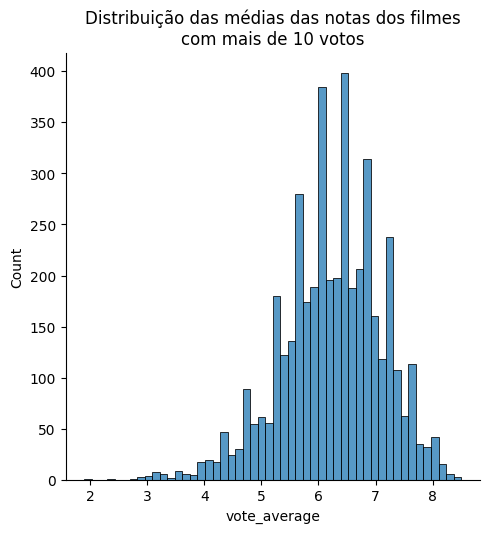

In [39]:
import matplotlib.pyplot as plt
mais_de_10_votos = tmdb.query("vote_count > 10")
sns.displot(mais_de_10_votos["vote_average"])
plt.title("Distribuição das médias das notas dos filmes\ncom mais de 10 votos")
plt.show()

In [40]:
## TIPO DE VARIAVEIS

# language -> categorica
# budget (orcamento) -> quantitativa continua

*Sobre a parte 3, aprendi a:*
- Identificar o tipo de variável observando seu conteúdo;
- Diferenciar uma variável categórica (qualitativa) nominal de uma ordinal;
- Compreender o que é uma variável quantitativa contínua e discreta e visualizar a diferença entre intervalos.

---
### **PARTE 4 - Visualizando os dados**

In [41]:
contagem_de_lingua = tmdb["original_language"].value_counts().to_frame().reset_index()
contagem_de_lingua.columns = ["original_language", "total"]
contagem_de_lingua.head()

,original_language,total
0,en,4505
1,fr,70
2,es,32
3,zh,27
4,de,27


<Axes: xlabel='original_language', ylabel='total'>

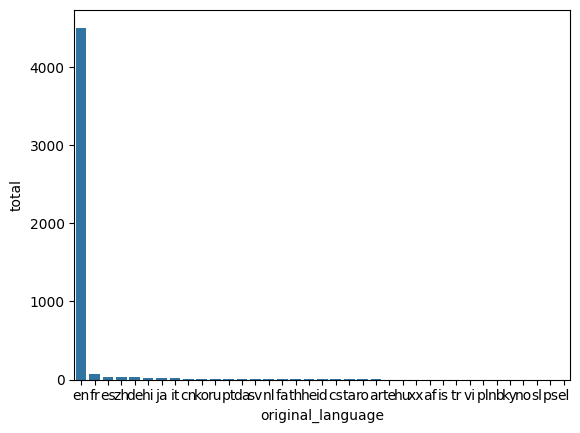

In [42]:
# Graficos de Barras sao bons para visualizar tamanhos entre as variaveis.
sns.barplot(data = contagem_de_lingua, x = "original_language", y = "total")

<Axes: xlabel='original_language', ylabel='count'>

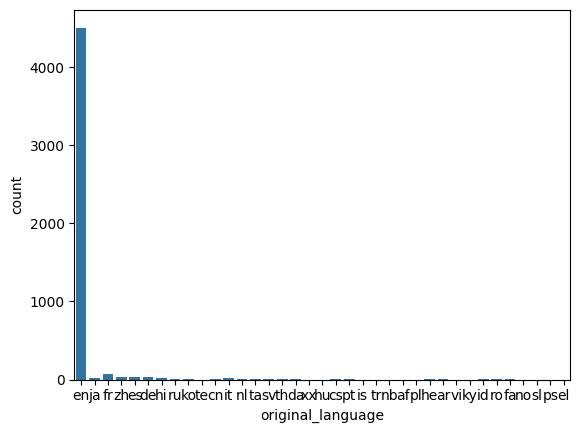

In [43]:
sns.countplot(data = tmdb, x = "original_language")

<Axes: ylabel='total'>

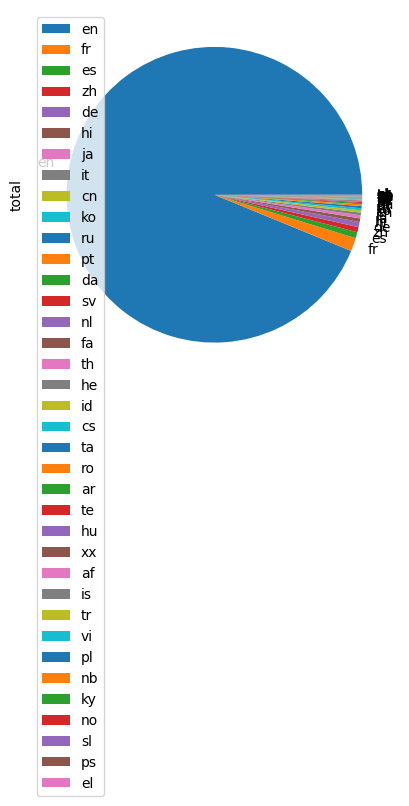

In [44]:
contagem_de_lingua.plot(kind="pie", y="total", labels=contagem_de_lingua["original_language"])

In [45]:
total_por_lingua = tmdb["original_language"].value_counts()
total_geral = total_por_lingua.sum()
total_de_ingles = total_por_lingua.loc["en"]
total_do_resto = total_geral - total_de_ingles
print(total_geral, total_de_ingles, total_do_resto)

4803 4505 298


In [46]:
dados = { 
    "Lingua": ["ingles", "outros"],
    "total": [total_de_ingles, total_do_resto]
}
dados = pd.DataFrame(dados)
dados.head()

,Lingua,total
0,ingles,4505
1,outros,298


<Axes: xlabel='Lingua', ylabel='total'>

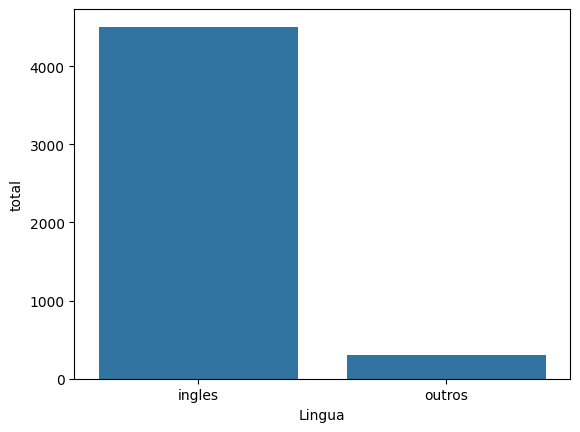

In [47]:
sns.barplot(data = dados, x = "Lingua", y = "total")

<Axes: ylabel='total'>

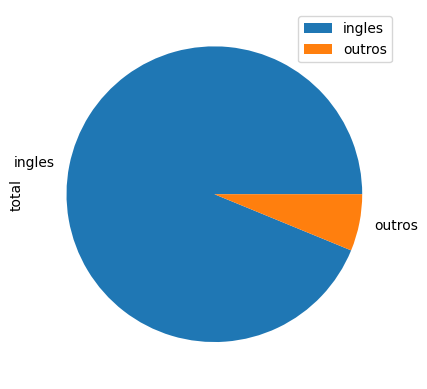

In [48]:
dados.plot(kind="pie", y="total", labels=dados["Lingua"])

O grafico de pizza(NUNCA USAR O 3D), será melhor mencionado quando se trata de:
 - Dados de categorias de gêneros homem/mulher/etc;
 - Quantidade ou porcentagem de respostas de pesquisas de sim/não;
 - Estudantes que concluíram o ensino médio a tempo ou não;
 - Outros dados binários/dicotômicos.

In [49]:
total_de_outros_filmes_por_lingua = tmdb.query("original_language != 'en'")["original_language"].value_counts()
total_de_outros_filmes_por_lingua.head()

original_language
fr    70
es    32
zh    27
de    27
hi    19
Name: count, dtype: int64

<Axes: xlabel='original_language', ylabel='count'>

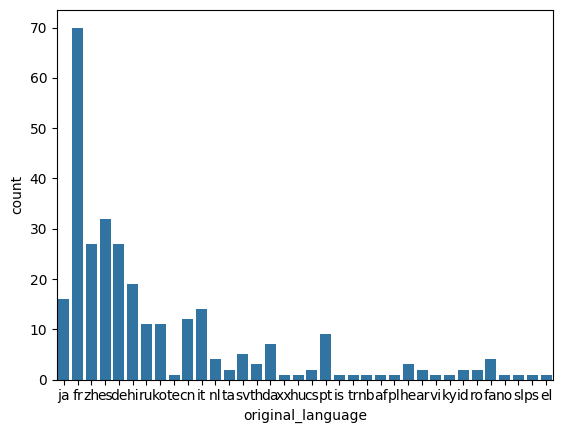

In [50]:
sns.countplot(data = tmdb.query("original_language != 'en'"), x = "original_language")

<Axes: xlabel='original_language', ylabel='count'>

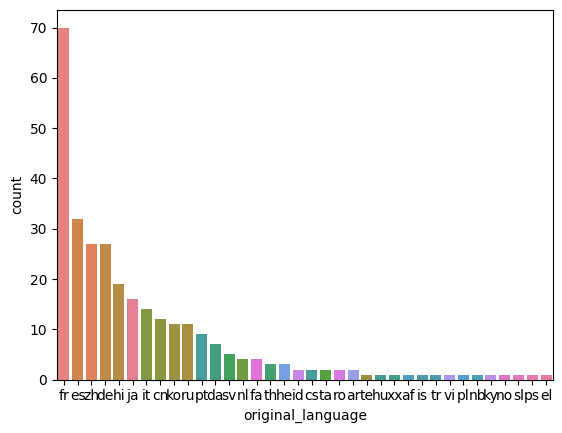

In [51]:
sns.countplot(data = tmdb.query("original_language != 'en'"), 
              order = total_de_outros_filmes_por_lingua.index, 
              hue = "original_language", 
              x = "original_language"
              )

In [52]:
sns.color_palette("mako")

[(0.18195582, 0.11955283, 0.23136943),
 (0.25307401, 0.23772973, 0.48316271),
 (0.21607792, 0.39736958, 0.61948028),
 (0.20344718, 0.56074869, 0.65649508),
 (0.25187832, 0.71827158, 0.67872193),
 (0.54578602, 0.8544913, 0.69848331)]

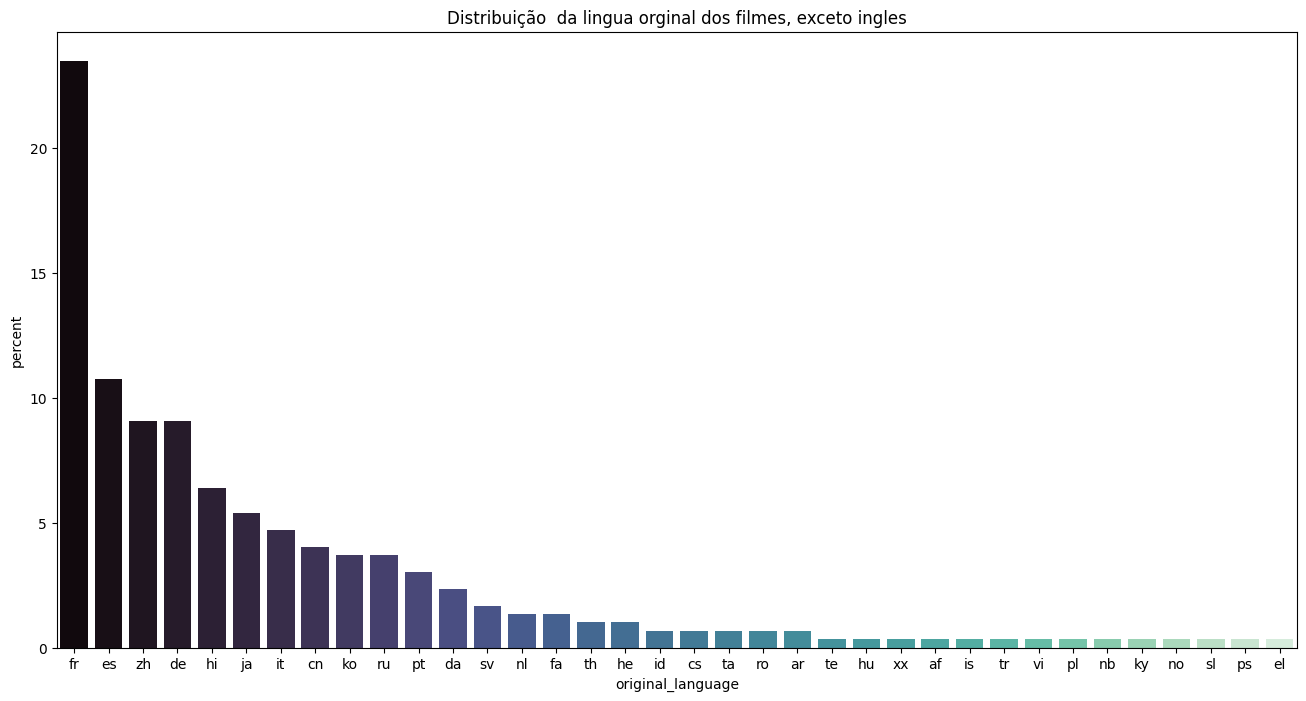

In [53]:
plt.figure(figsize=(16, 8))
sns.countplot(data = tmdb.query("original_language != 'en'"), 
              order = total_de_outros_filmes_por_lingua.index,
              palette="mako",
              hue = "original_language",
              hue_order = total_de_outros_filmes_por_lingua.index,
              stat="percent",
              x = "original_language"
              )
plt.title("Distribuição  da lingua orginal dos filmes, exceto ingles")
plt.show()

Sobre a parte 4, aprendi a:

- Ajustar as escalas de um gráfico aproveitando o espaço e melhorando a visualização dos dados;
- Ordenar os dados de um gráfico dando uma coesão a representação desses dados;
- Alterar cores e tons de um gráfico destacando elementos e melhorando a sua estética visual;
- Representar um gráfico de colunas com dados absolutos e relativos (porcentagem).

In [54]:
import numpy as np

filme1 = [2.5] * 10 + [3.5] * 10
filme2 = [5.0] * 10 + [1.0] * 10

In [55]:
print("Filme 1 - média:", np.mean(filme1))
print("Filme 1 - mediana:", np.median(filme1))

print("Filme 2 - média:", np.mean(filme2))
print("Filme 2 - mediana:", np.median(filme2))

Filme 1 - média: 3.0
Filme 1 - mediana: 3.0
Filme 2 - média: 3.0
Filme 2 - mediana: 3.0


(array([10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 10.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

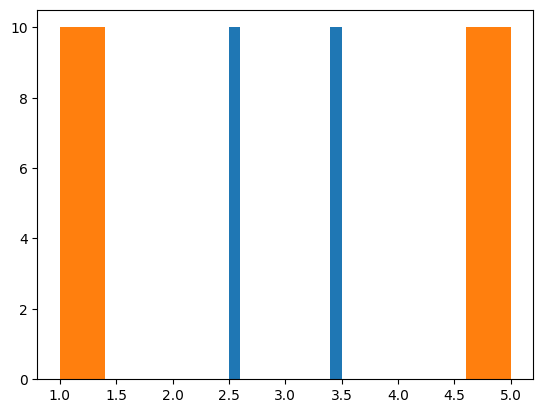

In [56]:
plt.hist(filme1)
plt.hist(filme2)

{'whiskers': [<matplotlib.lines.Line2D at 0x14e20d16710>,
 'caps': [<matplotlib.lines.Line2D at 0x14e20d17d90>,
 'boxes': [<matplotlib.lines.Line2D at 0x14e20aa5d20>,
 'medians': [<matplotlib.lines.Line2D at 0x14e1faf1cf0>,
 'fliers': [<matplotlib.lines.Line2D at 0x14e20524610>,
 'means': []}

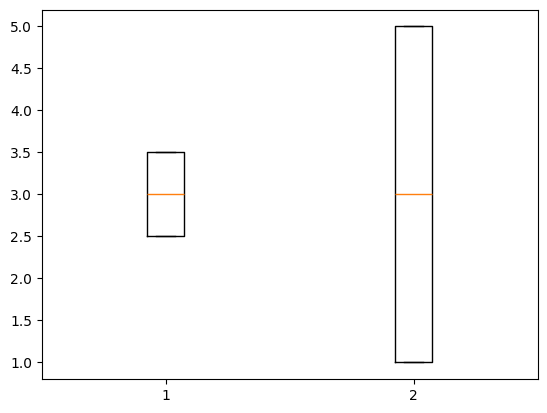

In [57]:
plt.boxplot([filme1, filme2])

### .STD ( DESVIO PADRAO )

O desvio padrão é a distância que os valores individuais estão da média do conjunto.

Quanto maior o desvio, maior é a disper~sao dos dados em torno da média. Quanto menor, menor é a dispersão.

###### " O desvio padrão auxilia na compreensão da variabilidade de um conjunto de dados e avalia o quão representativa é a média. Ele nos fornece uma medida da consistência ou inconsistência dos dados em relação à média e é comumente utilizado para medir a confiança e a margem de erro em cálculos "

In [58]:
filme0 = [3.0] * 20
np.mean(filme0)

np.float64(3.0)

In [59]:
np.std(filme0), np.std(filme1), np.std(filme2)

(np.float64(0.0), np.float64(0.5), np.float64(2.0))

C:\Users\user\AppData\Local\Temp\ipykernel_8408\2548851260.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([notas_do_toy_story, notas_do_jumanji], labels=["Toy Story", "Jumanji"])


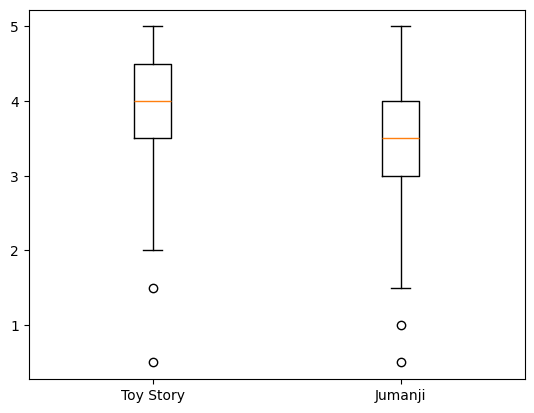

In [61]:
notas_do_toy_story = notas.query("filmeId == 1")["nota"]
notas_do_jumanji = notas.query("filmeId == 2")["nota"]

plt.boxplot([notas_do_toy_story, notas_do_jumanji], labels=["Toy Story", "Jumanji"])
plt.show()

<Axes: xlabel='filmeId', ylabel='nota'>

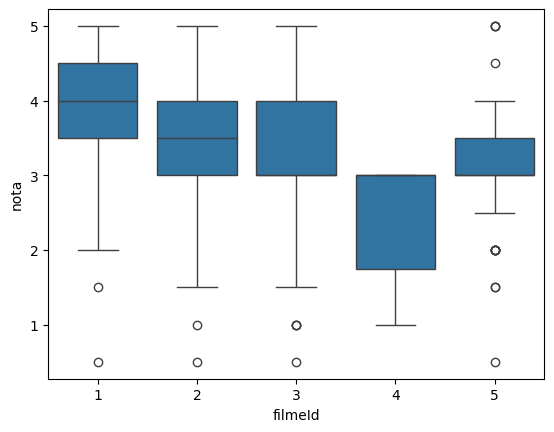

In [63]:
sns.boxplot(data=notas.query("filmeId in [1, 2, 3, 4, 5]"),
            x="filmeId",
            y="nota"
            )

C:\Users\user\AppData\Local\Temp\ipykernel_8408\1524262876.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=notas.query("filmeId in [1, 2, 3, 4, 5]"),


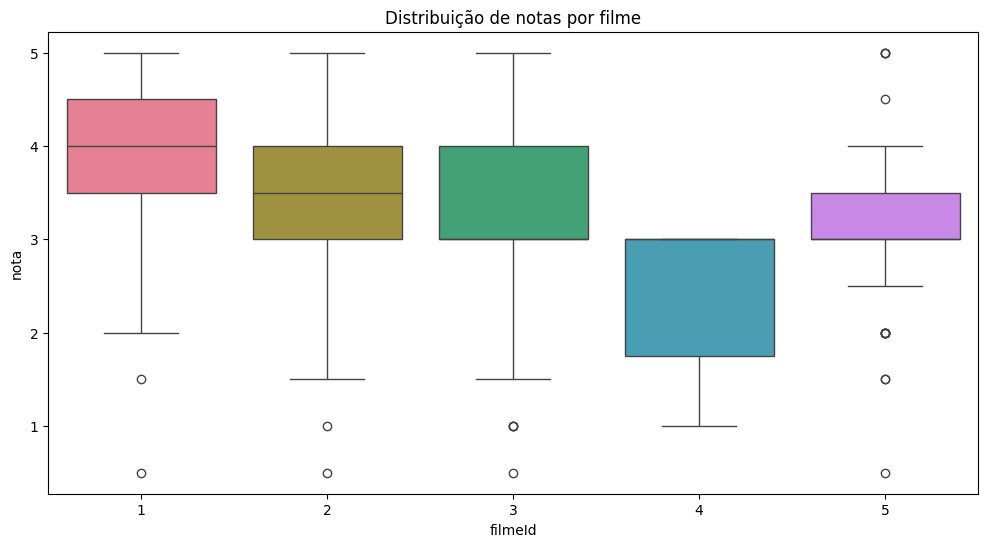

In [65]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=notas.query("filmeId in [1, 2, 3, 4, 5]"),
            x="filmeId",
            y="nota",
            palette="husl"
            )
plt.title("Distribuição de notas por filme")
plt.show()

### Analisando filmes que têm apenas 1 nota e, consequentemente, afeta o grafico deixando muito alta a média.

In [75]:
notas.groupby("filmeId").count()

,usuarioId,nota,momento
filmeId,,,
1,215,215,215
2,110,110,110
3,52,52,52
4,7,7,7
5,49,49,49
...,...,...,...
193581,1,1,1
193583,1,1,1
193585,1,1,1


In [76]:
notas["filmeId"].value_counts().tail()

filmeId
160341    1
160527    1
160836    1
163937    1
135534    1
Name: count, dtype: int64

In [77]:
notas.groupby("filmeId").count().query("nota == 1") #Identificando quais filmes possuem apenas 1 nota

,usuarioId,nota,momento
filmeId,,,
49,1,1,1
55,1,1,1
77,1,1,1
83,1,1,1
96,1,1,1
...,...,...,...
193581,1,1,1
193583,1,1,1
193585,1,1,1


Sobre essa parte, aprendi a:
- Diferenciar as medidas de tendência central e compreender o que cada uma representa;
- Utilizar a biblioteca Numpy para cálculos de média, mediana e desvio padrão de listas;
- Reconhecer a importância de trabalhar com as medidas de tendência central junto a dispersão de dados, a fim de comparar também como estes dados estão distribuídos;
- Comparar diferentes registros e investigar as diferenças entre eles visualmente por meio das medidas de tendência central e gráficos de distribuição de dados.